# Main Differential Equation Solver
- Units 
    - Volumes in meters^3
    - Surface Area in meters^2

In [344]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from scipy.integrate import solve_ivp

In [345]:
def get_vol_to_sa_df(path="./data/elevation-area-volume.csv"):
    df = pd.read_csv(path)
    df["elev"] = df["elev_ft_NAVD88"]
    df = df[["elev", "volume_m3", "area_m2"]]
    return df

def surface_area(volume, df):
    # Note: volume must be in m^3 and surface area will be returned in m^2
    return np.interp(volume, df["volume_m3"], df["area_m2"])

def get_vp_salinity_df(path="./data/vp-salinity.csv"):
    df = pd.read_csv(path)
    return df

def vp_reduction(salinity, df):
    return np.interp(salinity, df["salinity"], df["vp_reduction"])

def salinity(volume):
    return 1230618833073.342*(1/volume) + 171886.23798781837*(volume**(-1/3))

df_sa = get_vol_to_sa_df()

In [346]:
# True volume values
df = pd.read_csv('data/GSLLevelVol.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df = df[df["Date"] >= pd.to_datetime("2000-01-01")]
true_vol = df["Total_vol_m3"].to_numpy()
t_to_date = df["Date"].to_list()

## Inflow function

In [347]:
# Precipitation
prcp = pd.read_csv("data/historical_precipitation_values.csv")

def precipitation_empirical(t, V):
    return surface_area(V, df_sa) * np.interp(t, np.arange(len(prcp)), prcp["Precip"].to_numpy())

def precipitation(t, V):
    A, B, phi, C = 3.62510665e-04, 1.72209593e-02, 5.55109972e-01, 1.07152734e-03
    return surface_area(V, df_sa) * (A * np.sin(B * t + phi) + C)

In [348]:
# Getting historical inflow values
rivers = pd.read_csv("data/historical_river_inflow.csv")
rivers['time'] = pd.to_datetime(rivers['time'])
rivers = rivers[rivers["time"] >= pd.to_datetime("2000-01-01")]
riv_inflow_vals = rivers["value"].to_numpy()

In [349]:
def inflow_human(t, V):
    # function from inflow.ipynb, see file for function parameters
    seasonal_two_harmonics_human = lambda t, A1, phi1, A2, phi2, C, nu: (
    A1 * np.sin(2 * np.pi / 365 * t + phi1)
    + A2 * np.sin(2 * 2 * np.pi / 365 * t + phi2)
    + C) - (nu * t)

    params = [-28.97393599, -23.20200893, -18.43745932, 4.29250411, 45.52330359]
    return seasonal_two_harmonics_human(t, *params, nu=0.002) + precipitation(t, V)

def inflow(t, V):
    def seasonal_two_harmonics(t, A1, phi1, A2, phi2, C):
        omega = 2 * np.pi / 365
        return (
            A1 * np.sin(omega * t + phi1)
            + A2 * np.sin(2 * omega * t + phi2)
            + C
        )
    
    params = [-28.97393599, -23.20200893, -18.43745932, 4.29250411, 45.52330359]
    return seasonal_two_harmonics(t, *params) + precipitation(t, V)

def inflow_empircal(t, V):
    return 86400*np.interp(t, np.arange(len(riv_inflow_vals)), riv_inflow_vals) + precipitation_empirical(t, V)

## Outflow function

In [367]:
def get_vp_salinity_df(path="./data/vp-salinity.csv"):
    df = pd.read_csv(path)
    return df

def vp_reduction(salinity, df):
    return np.interp(salinity, df["salinity"], df["vp_reduction"])

def salinity(volume):
    return 1230618833073.342*(1/volume) + 171886.23798781837*(volume**(-1/3))

def salinity_n(volume):
    return 662924936948.8833*(1/volume) + 462860.60460320744*(volume**(-1/3))

def salinity_s(volume):
    return 1564606058225.5437*(1/volume) + -4334.001932641948*(volume**(-1/3))

# north to south surface area ratio
ratio = 0.615

def vp_reduction_improved(volume, df):
    sal_n = salinity_n(volume)
    sal_s = salinity_s(volume)
    return ratio*np.interp(sal_n, df["salinity"], df["vp_reduction"]) + (1 - ratio)*np.interp(sal_s, df["salinity"], df["vp_reduction"])

df_es = get_vp_salinity_df()

In [351]:
# Weather Functions (Simulating Seasons)
def simulate_temperature(t):
    # Simulates temperature in Celsius over a 365 day year
    # Peaks in summer (around month 7), lowest in winter
    mean_temp = 11.0
    amplitude = 15.0
    return mean_temp + amplitude * np.sin(2 * np.pi * (t - 213) / 365)

def simulate_wind_speed(t):
    # Simulates wind speed in m/s
    mean_wind = 3.0
    amplitude = 1.5
    return mean_wind + amplitude * np.sin(2 * np.pi * t / 182.5)

def calculate_vapor_pressures(T):
    RELATIVE_HUMIDITY = 0.2 # 40% average humidity
    # Magnus-Tetens formula for saturation vapor pressure (kPa)
    es = 0.611 * np.exp((17.27 * T) / (T + 237.3))
    # Actual vapor pressure
    ea = es * RELATIVE_HUMIDITY
    return es, ea

def evap_func(t, V, include_salinity=False, improved=False):
    WIND_COEFF_A = 0.001     # Empirical mass transfer coefficient
    WIND_COEFF_B = 0.0005    # Empirical mass transfer coefficient
    # Get current weather for month t
    T = simulate_temperature(t)
    u = simulate_wind_speed(t)

    # Calculate vapor pressures
    es, ea = calculate_vapor_pressures(T)
    if include_salinity:
        if not improved:
            vp_reduc = vp_reduction(salinity(V), df_es)
        if improved:
            vp_reduc = vp_reduction_improved(V, df_es)
        es = es*(1 - vp_reduc)
    # Calculate Dalton's Evaporation Rate (E)
    # E = f(wind) * (es - ea)
    wind_function = WIND_COEFF_A + WIND_COEFF_B * u
    E = wind_function * (es - ea)

    # Ensure evaporation doesn't go negative
    E = max(E, 0)

    # Calculate Area
    current_area = surface_area(V, df_sa)

    # The Final Differential
    dVdt = -E * current_area
    return dVdt

In [352]:
def outflow(t, V, include_salinity=False, improved=False):
    return evap_func(t, V, include_salinity=include_salinity, improved=improved)

## Main Solver

In [353]:
# Historical prediction
def ode(t, V):
    return inflow(t, V) + outflow(t, V, include_salinity=False)

# 9040 is number of days from 2000-01-01 to 2024-10-01
t_domain = (0, 9039) # Interval
t_eval = np.arange(9040)

# initial volume on 2000-01-01 is 21963728535.7859
y0 = np.array([21963728535.7859]) # Initial conditions

# Solve
sol = solve_ivp(ode, t_domain, y0, max_step=0.1, t_eval=t_eval)

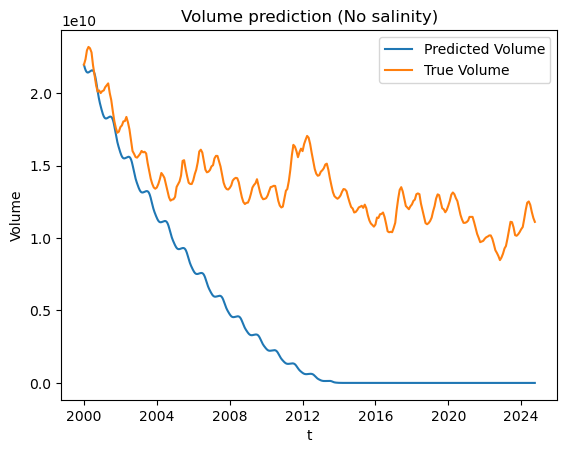

In [354]:
daily_dates = pd.date_range(start="2000-01-01", periods=9040, freq="D")
monthly_dates = pd.date_range(start="2000-01-01", periods=298, freq="MS")

plt.plot(daily_dates, sol.y[0], label="Predicted Volume")
plt.plot(monthly_dates, true_vol, label="True Volume")

plt.title("Volume prediction (No salinity)")
plt.legend()
plt.xlabel("t")
plt.ylabel("Volume")
plt.show()

In [355]:
# Historical prediction WITH SALINITY
def ode_sal(t, V):
    return inflow(t, V) + outflow(t, V, include_salinity=True)

# 9040 is number of days from 2000-01-01 to 2024-10-01
t_domain = (0, 9039) # Interval
t_eval = np.arange(9040)

# initial volume on 2000-01-01 is 21963728535.7859
y0 = np.array([21963728535.7859]) # Initial conditions

# Solve
sol_sal = solve_ivp(ode_sal, t_domain, y0, max_step=0.1, t_eval=t_eval)

In [356]:
print(salinity(21963728535.7859/2.19))

202.41010049530047


In [357]:
vp_reduction(1.5*202.41010049530047, df_es)

0.5258156818882356

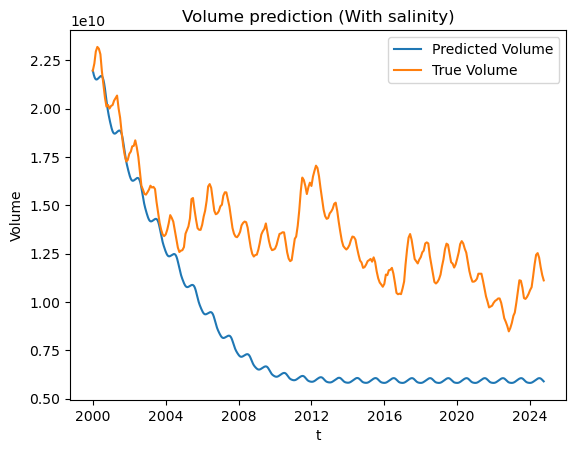

In [358]:
daily_dates = pd.date_range(start="2000-01-01", periods=9040, freq="D")
monthly_dates = pd.date_range(start="2000-01-01", periods=298, freq="MS")

plt.plot(daily_dates, sol_sal.y[0], label="Predicted Volume")
plt.plot(monthly_dates, true_vol, label="True Volume")

plt.title("Volume prediction (With salinity)")
plt.legend()
plt.xlabel("t")
plt.ylabel("Volume")
plt.show()

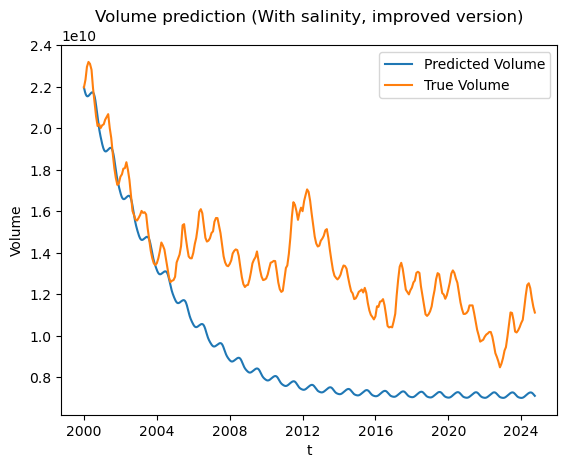

In [368]:
# Historical prediction WITH SALINITY
def ode_sal_improved(t, V):
    return inflow(t, V) + outflow(t, V, include_salinity=True, improved=True)

# 9040 is number of days from 2000-01-01 to 2024-10-01
t_domain = (0, 9039) # Interval
t_eval = np.arange(9040)

# initial volume on 2000-01-01 is 21963728535.7859
y0 = np.array([21963728535.7859]) # Initial conditions

# Solve
sol_sal = solve_ivp(ode_sal_improved, t_domain, y0, max_step=0.1, t_eval=t_eval)

daily_dates = pd.date_range(start="2000-01-01", periods=9040, freq="D")
monthly_dates = pd.date_range(start="2000-01-01", periods=298, freq="MS")

plt.plot(daily_dates, sol_sal.y[0], label="Predicted Volume")
plt.plot(monthly_dates, true_vol, label="True Volume")

plt.title("Volume prediction (With salinity, improved version)")
plt.legend()
plt.xlabel("t")
plt.ylabel("Volume")
plt.show()

In [366]:
# Historical prediction emprical inflow
def ode(t, V):
    return inflow_empircal(t, V) + outflow(t, V, include_salinity=False)

# 9040 is number of days from 2000-01-01 to 2024-10-01
t_domain = (0, 9039) # Interval
t_eval = np.arange(9040)

# initial volume on 2000-01-01 is 21963728535.7859
y0 = np.array([21963728535.7859]) # Initial conditions

# Solve
sol = solve_ivp(ode, t_domain, y0, max_step=0.1, t_eval=t_eval)

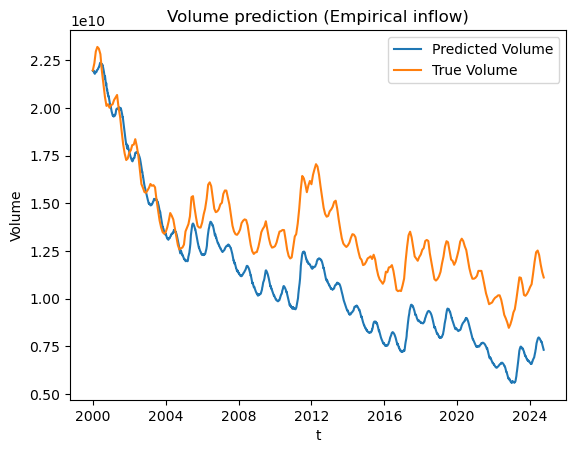

In [ ]:
daily_dates = pd.date_range(start="2000-01-01", periods=9040, freq="D")
monthly_dates = pd.date_range(start="2000-01-01", periods=298, freq="MS")

plt.plot(daily_dates, sol.y[0], label="Predicted Volume")
plt.plot(monthly_dates, true_vol, label="True Volume")

plt.title("Volume prediction (Empirical inflow)")
plt.legend()
plt.xlabel("t")
plt.ylabel("Volume")
plt.show()

In [370]:
# Historical prediction emprical inflow with salinity
def ode(t, V):
    return inflow_empircal(t, V) + outflow(t, V, include_salinity=True)

# 9040 is number of days from 2000-01-01 to 2024-10-01
t_domain = (0, 9039) # Interval
t_eval = np.arange(9040)

# initial volume on 2000-01-01 is 21963728535.7859
y0 = np.array([21963728535.7859]) # Initial conditions

# Solve
sol = solve_ivp(ode, t_domain, y0, max_step=0.1, t_eval=t_eval)

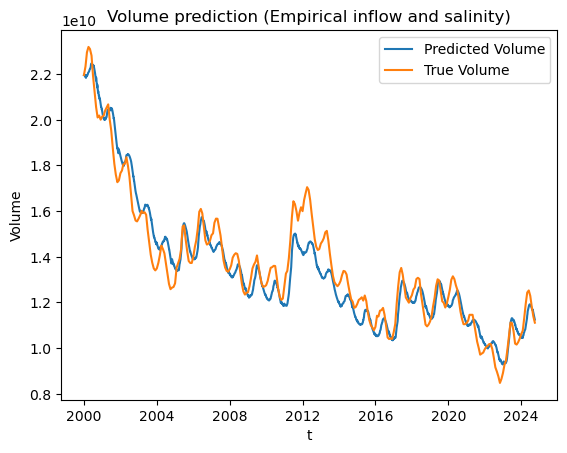

In [371]:
daily_dates = pd.date_range(start="2000-01-01", periods=9040, freq="D")
monthly_dates = pd.date_range(start="2000-01-01", periods=298, freq="MS")

plt.plot(daily_dates, sol.y[0], label="Predicted Volume")
plt.plot(monthly_dates, true_vol, label="True Volume")

plt.title("Volume prediction (Empirical inflow and salinity)")
plt.legend()
plt.xlabel("t")
plt.ylabel("Volume")
plt.show()

# EDA

In [ ]:
seasonal_two_harmonics_human = lambda t, A1, phi1, A2, phi2, C, nu: (
    A1 * np.sin(2 * np.pi / 365 * t + phi1)
    + A2 * np.sin(2 * 2 * np.pi / 365 * t + phi2)
    + C) - (nu * t)

params = [-28.97393599, -23.20200893, -18.43745932, 4.29250411, 45.52330359]

def day_values(t, V):
    print("Evap:", evap_func(t, V))
    print("Full Inflow:", inflow(t, V))
    print("Inflow from rivers:", 86400*seasonal_two_harmonics_human(t, *params, nu=0.002))
    print("Inflow from rivers empirical:", 86400*np.interp(t, np.arange(len(riv_inflow_vals)), riv_inflow_vals))
    print("Precip:", precipitation(t, V))
    print("Precip Empircal:", precipitation_empirical(t, V))
    print("-"*20)

day_values(1, 19078920146.2373)
day_values(10, 19331834782.1717)
day_values(100, 24335348662.2346)

Evap: -17137147.867711265
Full Inflow: 5112699.491854184
Inflow from rivers: 3081746.478745199
Inflow from rivers empirical: 9125711.7696
Precip: 5112663.821492162
Precip Empircal: 31752004.657039944
--------------------
Evap: -16504250.464790542
Full Inflow: 5344241.026189894
Inflow from rivers: 3362659.77400959
Inflow from rivers empirical: 7014320.54784
Precip: 5344202.086516584
Precip Empircal: 31025734.340018682
--------------------
Evap: -4421862.599454769
Full Inflow: 6656574.885267093
Inflow from rivers: 3557435.627713775
Inflow from rivers empirical: 6681586.8211199995
Precip: 6656533.511243624
Precip Empircal: 0.0
--------------------
